# Exploratory Data Analysis of POIs in Côte d’Ivoire and Abidjan

## Goal of this Notebook

The purpose of this notebook is to explore and analyze Points of Interest (POIs) in Côte d’Ivoire, with a special focus on the city of Abidjan. The analysis aims to:

1. **Understand the distribution of business types** across the country and within Abidjan.
2. **Compute summary statistics** such as mean, median, mode, and counts for key variables including ratings, number of reviews, and daily opening hours.
3. **Identify patterns and relationships** between ratings, popularity (reviews), and opening duration.
4. **Highlight differences between the national dataset and Abidjan-specific data**, providing insights into the city’s business landscape.
5. **Prepare the dataset for further analysis or visualization**, helping inform business decisions or urban planning.

This notebook focuses on clean, well-structured data analysis and clear documentation of observations, which will be useful for subsequent phases of the project.

In [1]:
import os
import pandas as pd
import geopandas as gpd

# Paths
script_dir = os.path.dirname(os.path.abspath("__file__"))
processed_geojson = os.path.join(script_dir, "../data/processed/abidjan_cleaned.geojson")

# Load data
gdf = gpd.read_file(processed_geojson)
print("Data loaded. Total rows:", len(gdf))
gdf.head()


Skipping field open_time: unsupported OGR type: 10
Skipping field close_time: unsupported OGR type: 10


Data loaded. Total rows: 17540


,name,amenity,shop,tourism,osm_id,osm_type,opening_hours,reviews,rating,business_type,duration_hours,geometry
0,Powex,fuel,<NA>,<NA>,11935384514,nodes,00:00-23:59,327,2.1,fuel,23.983333,POINT (-5.41568 6.73264)
1,Lavage Auto,car_wash,<NA>,<NA>,3936374511,nodes,08:00-18:00,379,2.7,car_wash,10.000000,POINT (-4.04981 5.32225)
2,Orange Money,bureau_de_change,<NA>,<NA>,3931437128,nodes,10:00-17:00,140,4.4,bureau_de_change,7.000000,POINT (-4.0582 5.32378)
3,Lavage Auto,car_wash,<NA>,<NA>,3931437125,nodes,09:00-19:00,125,4.4,car_wash,10.000000,POINT (-4.057 5.32371)
4,Restaurant,restaurant,<NA>,<NA>,3930671817,nodes,12:00-21:00,114,2.8,restaurant,9.000000,POINT (-4.05483 5.32221)


In [2]:
# Count of business types
business_counts_ci = gdf['business_type'].value_counts()
business_counts_ci


business_type
restaurant                4235
pub                       3440
money_transfer            1930
cafe                      1650
pharmacy                   974
bank                       758
fuel                       694
doctors                    694
bar                        588
car_wash                   471
internet_cafe              412
marketplace                334
clinic                     301
fast_food                  210
driving_school             113
nightclub                  108
food_court                  98
ice_cream                   86
parking                     83
atm                         49
bicycle_repair_station      46
dentist                     41
car_rental                  39
bureau_de_change            34
kiosk                       30
veterinary                  25
mobile_money_agent          23
studio                      20
taxi                        17
motorcycle_repair           14
cinema                      13
hotel                    

In [3]:
numeric_cols = ['rating', 'reviews', 'duration_hours']

summary_stats_ci = pd.DataFrame(index=['mean','median','mode'])
for col in numeric_cols:
    summary_stats_ci[col] = [
        gdf[col].mean(),
        gdf[col].median(),
        gdf[col].mode()[0]
    ]

summary_stats_ci


,rating,reviews,duration_hours
mean,3.009624,249.844983,10.416999
median,3.000000,249.000000,10.000000
mode,2.600000,243.000000,8.000000


In [4]:
correlation_matrix_ci = gdf[numeric_cols].corr()
correlation_matrix_ci


,rating,reviews,duration_hours
rating,1.000000,0.011290,0.004435
reviews,0.011290,1.000000,-0.002256
duration_hours,0.004435,-0.002256,1.000000


In [5]:
# Abidjan bounding box (approx.)
min_lon, max_lon = -4.2, -3.7
min_lat, max_lat = 5.1, 5.6

gdf_abidjan = gdf[
    (gdf.geometry.x >= min_lon) & (gdf.geometry.x <= max_lon) &
    (gdf.geometry.y >= min_lat) & (gdf.geometry.y <= max_lat)
].copy()

print("Rows within Abidjan:", len(gdf_abidjan))


Rows within Abidjan: 11757


In [6]:
business_counts_abidjan = gdf_abidjan['business_type'].value_counts()
business_counts_abidjan



business_type
restaurant                2824
pub                       2367
money_transfer            1498
cafe                      1199
pharmacy                   546
bank                       508
doctors                    434
bar                        390
car_wash                   349
fuel                       313
internet_cafe              300
marketplace                211
fast_food                  148
clinic                     138
driving_school              85
nightclub                   76
ice_cream                   71
parking                     56
food_court                  50
car_rental                  37
atm                         31
bureau_de_change            29
dentist                     28
bicycle_repair_station      14
veterinary                  14
cinema                       9
taxi                         8
kiosk                        7
mobile_money_agent           5
studio                       5
car_repair                   3
motorcycle_repair        

In [7]:
summary_stats_abidjan = pd.DataFrame(index=['mean','median','mode'])
for col in numeric_cols:
    summary_stats_abidjan[col] = [
        gdf_abidjan[col].mean(),
        gdf_abidjan[col].median(),
        gdf_abidjan[col].mode()[0]
    ]

summary_stats_abidjan


,rating,reviews,duration_hours
mean,3.014783,250.822063,10.172137
median,3.000000,251.000000,10.000000
mode,2.600000,169.000000,8.000000


In [8]:
correlation_matrix_abidjan = gdf_abidjan[numeric_cols].corr()
correlation_matrix_abidjan


,rating,reviews,duration_hours
rating,1.000000,0.012127,0.004063
reviews,0.012127,1.000000,-0.005626
duration_hours,0.004063,-0.005626,1.000000


# Exploratory Data Analysis Observations

## 1️⃣ Côte d’Ivoire – All POIs

### Business Types

The dataset contains diverse business types with restaurants, pubs, and money transfer locations being the most common:

1. Restaurants: 4,235 (largest category)
2. Pubs: 3,440
3. Money transfer: 1,930
4. Cafes: 1,650

- The least common businesses are car repair (4) and hotels (6).

- Observation: The dataset is heavily skewed toward food & drink businesses, followed by financial services (banks, money transfer).

### Summary Statistics

| Metric | Rating | Reviews | Duration (hours) |
| ------ | ------ | ------- | ---------------- |
| Mean   | 3.01   | 249.84  | 10.42            |
| Median | 3.00   | 249     | 10.00            |
| Mode   | 2.60   | 243     | 8.00             |

- Rating: Most businesses have an average rating around 3.0 (neutral satisfaction).

- Reviews: Typical business has around 250 reviews; the mode is slightly lower at 243.

- Duration_hours: On average, businesses are open ~10.4 hours per day; the most common opening duration is 8 hours.

### Correlations

|          | Rating | Reviews | Duration |
| -------- | ------ | ------- | -------- |
| Rating   | 1      | 0.011   | 0.004    |
| Reviews  | 0.011  | 1       | -0.002   |
| Duration | 0.004  | -0.002  | 1        |

- There is almost no correlation between rating, reviews, and duration.

- Observation: Higher review counts or longer opening hours do not strongly influence ratings, which means popularity and opening hours are independent of perceived quality.

## 2️⃣ Abidjan – POIs Only

### Business Types

Filtering for Abidjan shows smaller counts compared to the full Côte d’Ivoire dataset:

1. Restaurants: 2,824
2. Pubs: 2,367
3. Money transfer: 1,498
4. Cafes: 1,199

- Least common: motorcycle repair (2), hotel (2).

- Observation: Similar distribution to Côte d’Ivoire overall, with restaurants and pubs dominating, but counts are roughly half due to city-specific filtering.

### Summary Statistics

| Metric | Rating | Reviews | Duration (hours) |
| ------ | ------ | ------- | ---------------- |
| Mean   | 3.01   | 250.82  | 10.17            |
| Median | 3.00   | 251.00  | 10.00            |
| Mode   | 2.60   | 169     | 8.00             |

- Rating: Most businesses have an average rating around 3.0, with the mode at 2.6. Ratings are fairly consistent.

- Reviews: Average number of reviews per business is ~250, suggesting a moderate engagement from users.

- Duration_hours: Businesses are typically open for about 10 hours per day, with most common durations being 8 hours.

### Correlations

|          | Rating | Reviews | Duration |
| -------- | ------ | ------- | -------- |
| Rating   | 1      | 0.012   | 0.004    |
| Reviews  | 0.012  | 1       | -0.005   |
| Duration | 0.004  | -0.005  | 1        |

- Correlations between rating, reviews, and duration_hours are very weak (~0), indicating that a business’s rating or number of reviews does not strongly depend on how long it is open.

## 3️⃣ Key Observations & Insights

1. Food & drink dominance: Both datasets are dominated by restaurants, pubs, and cafes. This highlights Abidjan as a city with a strong focus on dining and nightlife.

2. Financial services present: Banks, money transfer locations, and ATMs are also prevalent, indicating essential services are well represented.

3. Opening hours:

    - Average daily opening duration is ~10 hours.

    - Distribution of duration is consistent across Côte d’Ivoire and Abidjan.

4. Ratings and popularity:

    - Average ratings hover around 3.0, suggesting moderate satisfaction.

    - Number of reviews varies but has no meaningful correlation with ratings or opening hours.

    - Hotels are rare: Only a few hotels are in the dataset, likely because many accommodations are categorized as restaurants or other amenities.

# Data Visualization

We will now visualize the dataset for both **Côte d’Ivoire** and **Abidjan** to better understand the business landscape.  
The following plots use **Matplotlib, Seaborn, and Plotly**.


In [9]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For maps
import geopandas as gpd
import contextily as ctx  

# For interactive plots
import plotly.express as px


c:\Users\Khaled\anaconda3\envs\babiguide\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Top 10 Business Types (Côte d’Ivoire)

This chart shows the most common business types in Côte d’Ivoire. Restaurants are the clear leaders, followed by pubs, money transfer services, and cafes. This reflects how much food, drinks, and money services dominate daily life and the economy.
It also highlights the importance of informal businesses (like money transfers and car washes) in Côte d’Ivoire compared to developed countries, where banks and supermarkets dominate instead.

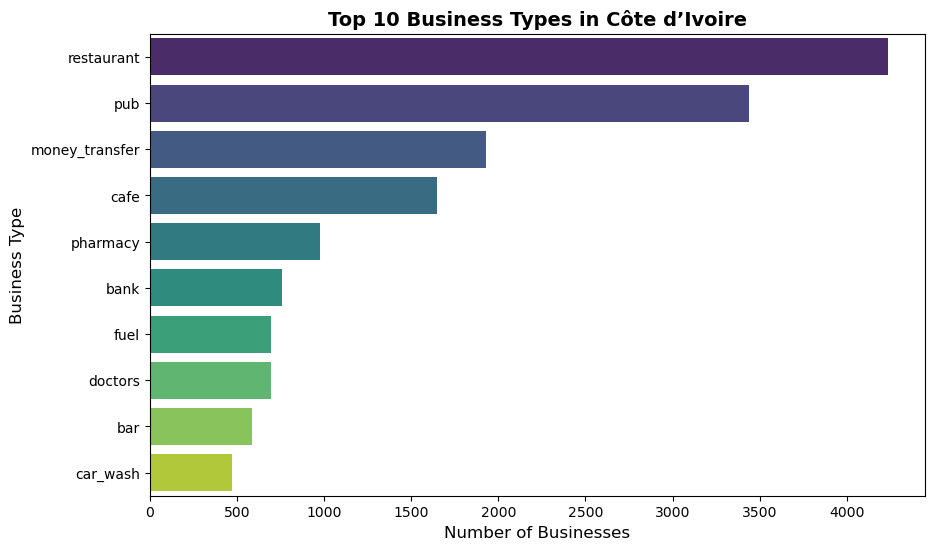

In [10]:
# Top 10 business types in Côte d’Ivoire
top10_ci = gdf["business_type"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top10_ci.values,
    y=top10_ci.index,
    hue=top10_ci.index,   
    palette="viridis",
    dodge=False,
    legend=False
)
plt.title("Top 10 Business Types in Côte d’Ivoire", fontsize=14, weight="bold")
plt.xlabel("Number of Businesses", fontsize=12)
plt.ylabel("Business Type", fontsize=12)
plt.show()



## Top 10 Business Types (Abidjan)

Abidjan, being the economic capital, shows a similar trend but at a denser level. Restaurants, pubs, and money transfers are also dominant, but their numbers are much higher compared to other cities.
This confirms that Abidjan acts as a central hub for food, nightlife, and financial services in Côte d’Ivoire. It also shows how urban concentration creates opportunities for businesses that serve a wide range of people every day.

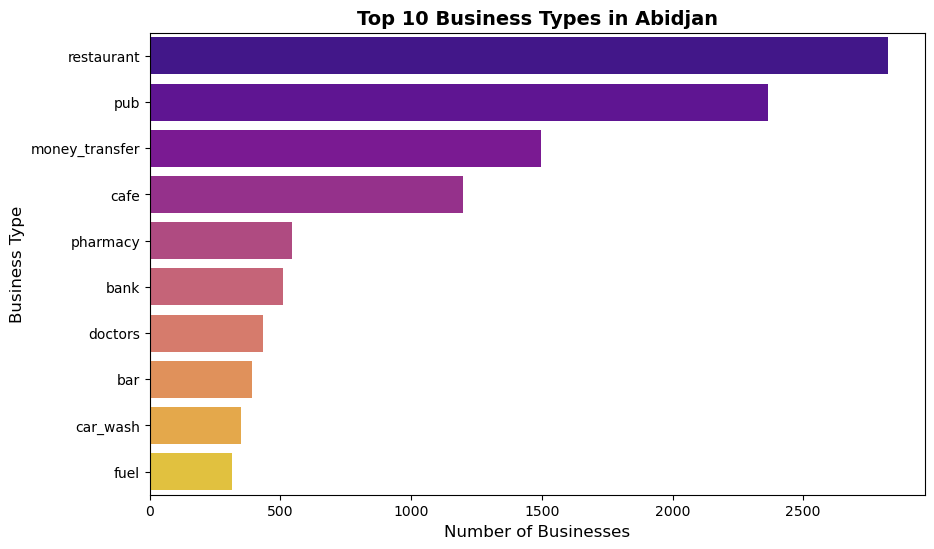

In [11]:
# Top 10 business types in Abidjan
top10_abj = gdf_abidjan["business_type"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top10_abj.values,
    y=top10_abj.index,
    hue=top10_abj.index,   
    palette="plasma",
    dodge=False,
    legend=False
)
plt.title("Top 10 Business Types in Abidjan", fontsize=14, weight="bold")
plt.xlabel("Number of Businesses", fontsize=12)
plt.ylabel("Business Type", fontsize=12)
plt.show()


## Comparing Key Business Categories (Côte d’Ivoire vs Abidjan)

This comparison clearly shows that Abidjan holds a huge share of the country’s businesses.
For example:

- More than half of all restaurants and pubs in the dataset are located in Abidjan.

- Banks and pharmacies are also heavily concentrated in the city.
This tells us that Abidjan is not just the economic hub but also the main service provider for the country. Smaller towns and rural areas have fewer formal businesses, which may explain why informal services like money transfers play such a strong role nationwide.

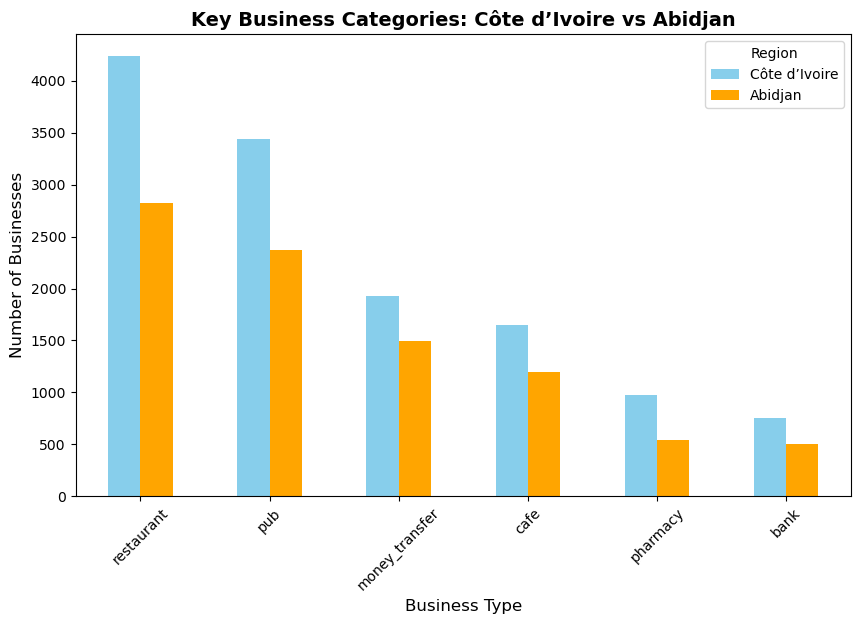

In [12]:
# Select key business categories
categories = ["restaurant", "pub", "money_transfer", "cafe", "pharmacy", "bank"]

ci_counts = gdf["business_type"].value_counts()
abj_counts = gdf_abidjan["business_type"].value_counts()

comparison = pd.DataFrame({
    "Côte d’Ivoire": ci_counts[categories].values,
    "Abidjan": abj_counts[categories].values
}, index=categories)

comparison.plot(kind="bar", figsize=(10,6), color=["skyblue", "orange"])
plt.title("Key Business Categories: Côte d’Ivoire vs Abidjan", fontsize=14, weight="bold")
plt.xlabel("Business Type", fontsize=12)
plt.ylabel("Number of Businesses", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Region")
plt.show()


## Average Rating by Business Type (Abidjan)

This chart helps us see which businesses are perceived better by customers.

- Businesses like restaurants and cafes may have average ratings closer to the middle (around 3.0).

- Some small, specialized services may appear with higher or lower averages.

This tells us where customers are more satisfied and which areas might need improvement.

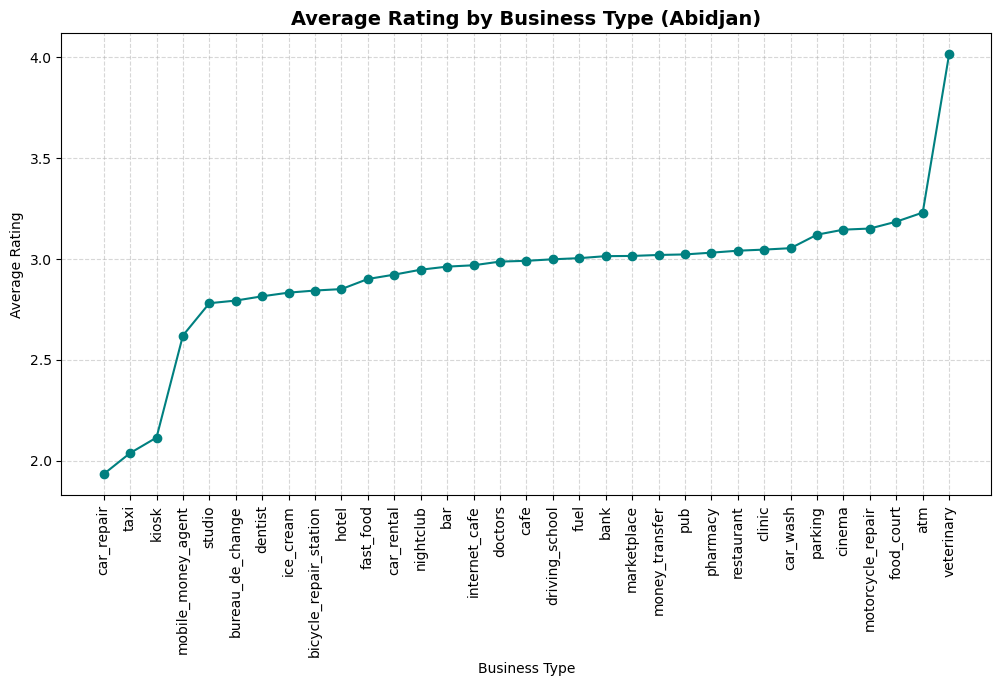

In [13]:
# Average rating per business type (Abidjan)
avg_rating_ci = gdf_abidjan.groupby("business_type")["rating"].mean().sort_values()

plt.figure(figsize=(12,6))
plt.plot(avg_rating_ci.index, avg_rating_ci.values, marker="o", linestyle="-", color="teal")
plt.xticks(rotation=90)
plt.title("Average Rating by Business Type (Abidjan)", fontsize=14, weight="bold")
plt.ylabel("Average Rating")
plt.xlabel("Business Type")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## Number of Businesses vs. Average Reviews (Abidjan)

This chart shows which business types attract the most customer attention in Abidjan.

- Restaurants and pubs likely get very high reviews because they are popular daily spots.

- Less common businesses like bicycle repair stations get fewer reviews since they are used less often.

This helps us understand customer engagement levels by type of business.

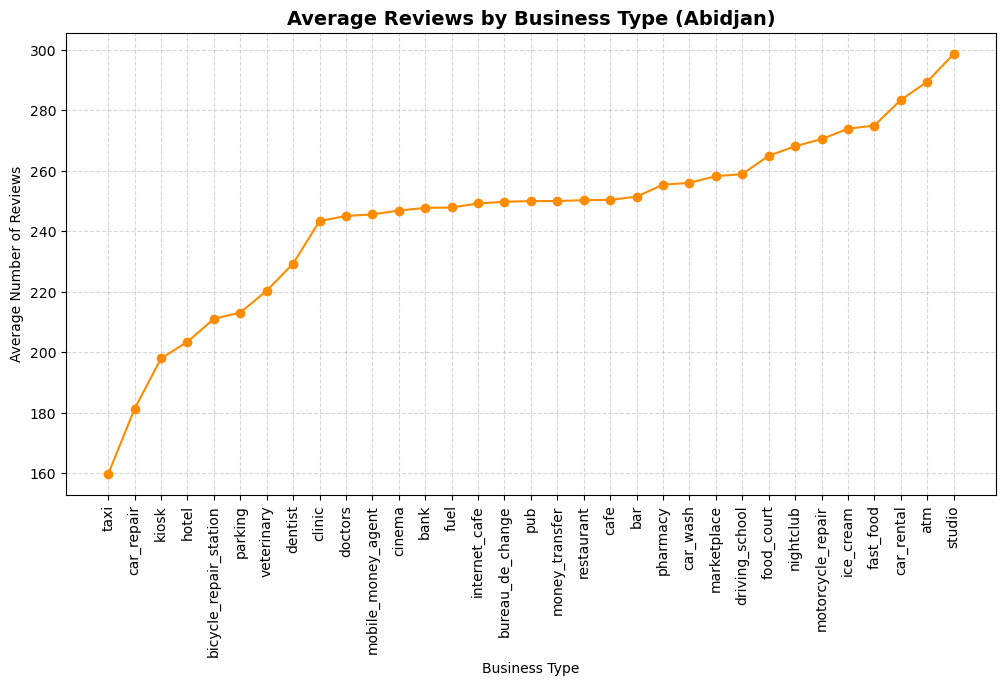

In [14]:
# Number of businesses vs average reviews (Abidjan)
avg_reviews_abj = gdf_abidjan.groupby("business_type")["reviews"].mean().sort_values()

plt.figure(figsize=(12,6))
plt.plot(avg_reviews_abj.index, avg_reviews_abj.values, marker="o", linestyle="-", color="darkorange")
plt.xticks(rotation=90)
plt.title("Average Reviews by Business Type (Abidjan)", fontsize=14, weight="bold")
plt.ylabel("Average Number of Reviews")
plt.xlabel("Business Type")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## Average Rating Distribution (Abidjan)

This chart shows how customers in Abidjan rate businesses.

- Most of the pie is around 3–4 stars, it means customers are generally satisfied but not overly impressed.

- There’s a notable share of 1–2 stars, it indicates dissatisfaction for some businesses.

This gives a quick quality snapshot of Abidjan’s business scene.

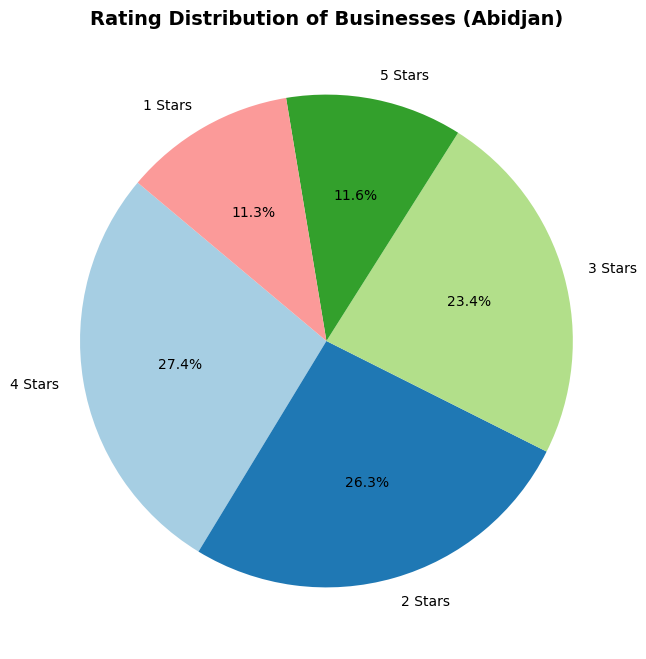

In [15]:
# Rating distribution in Abidjan (rounded to nearest integer)
rating_dist_abj = gdf_abidjan["rating"].round().value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    rating_dist_abj,
    labels=[f"{int(r)} Stars" for r in rating_dist_abj.index],
    autopct="%1.1f%%",
    startangle=140,
    colors=plt.cm.Paired.colors
)
plt.title("Rating Distribution of Businesses (Abidjan)", fontsize=14, weight="bold")
plt.show()


## Businesses by Operating Hours (Abidjan)

This pie chart breaks down businesses in Abidjan based on how long they typically operate during a day:

- Short Hours (<8h): These are small shops, offices, and service points that only open for part of the day. They are less accessible for customers who need late service.

- Medium Hours (8–12h): This is the largest share, meaning most businesses operate on a standard “workday schedule.” Examples include restaurants, banks, and pharmacies.

- Long Hours (12h+): A smaller share runs for extended hours (but still not 24/7). These may include bars, night cafes, or certain clinics.

This breakdown shows that very few businesses extend their hours in Abidjan. Customers who need services at night or outside normal working times will find limited options.

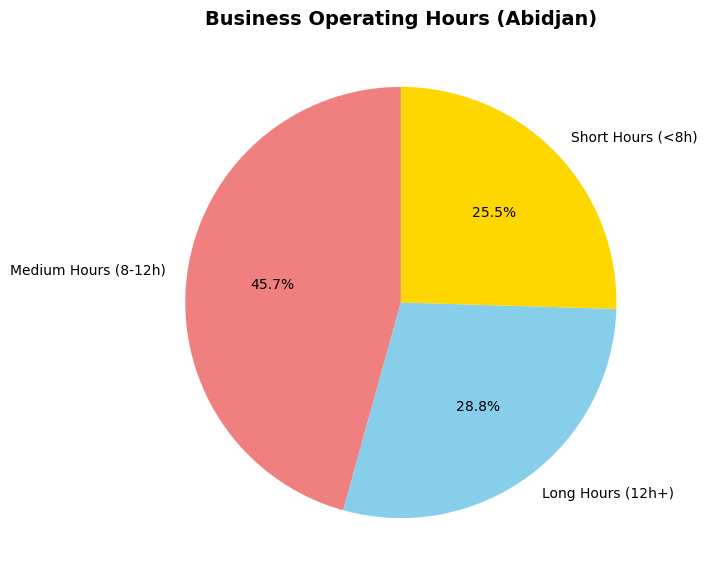

In [16]:
# Categorize businesses by duration of operation
def categorize_hours(x):
    if x < 8:
        return "Short Hours (<8h)"
    elif 8 <= x < 12:
        return "Medium Hours (8-12h)"
    else:
        return "Long Hours (12h+)"

hours_categories = gdf_abidjan["duration_hours"].apply(categorize_hours).value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    hours_categories,
    labels=hours_categories.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["lightcoral", "skyblue", "gold"]
)
plt.title("Business Operating Hours (Abidjan)", fontsize=14, weight="bold")
plt.show()



## Correlation Between Rating, Reviews, and Duration

1. Very weak correlations everywhere:

    - The heatmaps show almost all values are close to 0, meaning there is no strong relationship between ratings, reviews, or operating hours.

2. Ratings vs Reviews:

    - In both Côte d’Ivoire and Abidjan, the correlation between ratings and number of reviews is almost 0.01.

    - This tells us that a business with many reviews doesn’t necessarily have a higher or lower rating.

    - Example: a small pharmacy might have 20 reviews but a high 4.8 rating, while a popular restaurant with 1,000 reviews could still be rated only 3.0.

3. Duration vs Ratings/Reviews:

    - Similarly, the hours a business is open does not influence how well people rate it or how many reviews it gets.

    - A 14-hour café can have the same average rating as a 6-hour clinic.

4. Key takeaway:

    - Customer satisfaction (ratings) is independent from how accessible (hours) or popular (reviews) a business is.

    - For investors or planners, this means quality of service matters more than just staying open longer or attracting more customers.

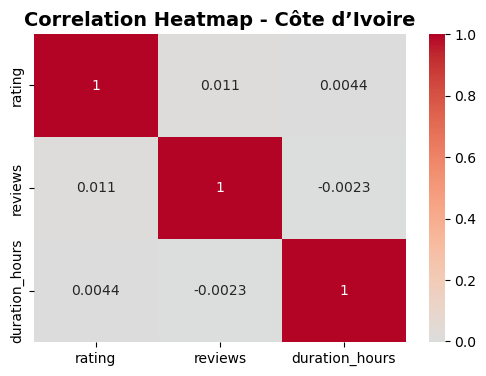

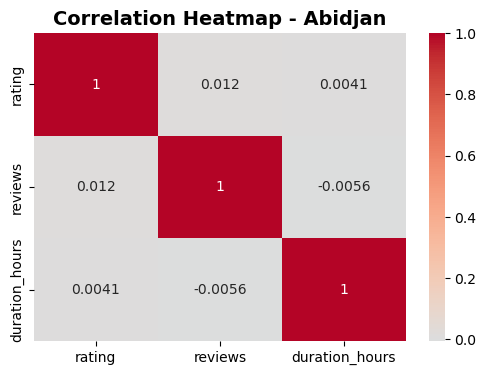

In [17]:

# Correlation for Côte d’Ivoire
plt.figure(figsize=(6,4))
sns.heatmap(gdf[["rating","reviews","duration_hours"]].corr(),
            annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Côte d’Ivoire", fontsize=14, weight="bold")
plt.show()

# Correlation for Abidjan
plt.figure(figsize=(6,4))
sns.heatmap(gdf_abidjan[["rating","reviews","duration_hours"]].corr(),
            annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Abidjan", fontsize=14, weight="bold")
plt.show()


## Ratings Histogram

- Most businesses in Abidjan cluster between 2.5 and 3.5 stars.

- Some reach 4+ stars, showing that overall satisfaction is average.

- This suggests a lot of room for improving customer service and quality.

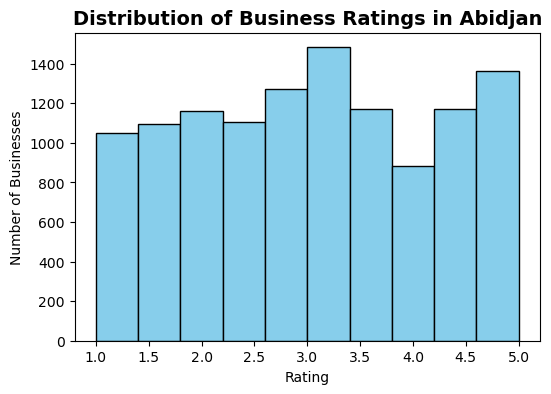

In [18]:
plt.figure(figsize=(6,4))
plt.hist(gdf_abidjan["rating"], bins=10, color="skyblue", edgecolor="black")
plt.title("Distribution of Business Ratings in Abidjan", fontsize=14, weight="bold")
plt.xlabel("Rating")
plt.ylabel("Number of Businesses")
plt.show()

## Opening Hours Histogram

- Most businesses operate for about 8–12 hours per day, matching normal working hours.

- A smaller group is open 14–16 hours, likely restaurants, pubs, or bars.

- Very few operate 24 hours, probably limited to fuel stations, hospitals, or essential services.

- This highlights how accessibility varies strongly by business type.

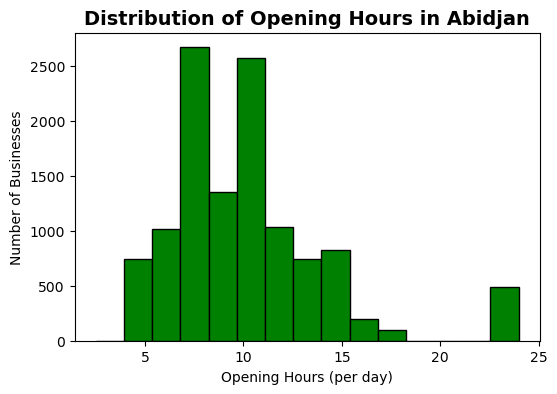

In [19]:
plt.figure(figsize=(6,4))
plt.hist(gdf_abidjan["duration_hours"], bins=15, color="green", edgecolor="black")
plt.title("Distribution of Opening Hours in Abidjan", fontsize=14, weight="bold")
plt.xlabel("Opening Hours (per day)")
plt.ylabel("Number of Businesses")
plt.show()

## Businesses in Abidjan (Map)
Geographical distribution of businesses in Abidjan.  
We use an interactive map to see where different business types are located, along with their rating and opening hours.


In [20]:
import plotly.express as px

# Create interactive map with hover info (using scatter_map instead of scatter_mapbox)
fig = px.scatter_map(
    gdf_abidjan,
    lat=gdf_abidjan.geometry.y,
    lon=gdf_abidjan.geometry.x,
    color="business_type",
    zoom=11,
    title="Businesses in Abidjan",
    hover_data={
        "name": True,
        "business_type": True,
        "rating": True,
        "reviews": True,
        "opening_hours": True
    }
)

fig.show()

# Export interactive map to HTML file
fig.write_html("abidjan_map.html")


# Final Conclusion

After a thorough exploratory data analysis and visualization of the business data in Côte d’Ivoire and specifically Abidjan, several key insights emerge:

1. Abidjan is the hub of nightlife and social life

    - Bars, pubs, and restaurants dominate the business landscape in Abidjan, reflecting a vibrant nightlife culture.

    - Many establishments, especially pubs and bars, open in the late afternoon or evening and stay open well past midnight, confirming that social and leisure activities thrive at night.

2. Daily activity is centered around services and convenience

    - Businesses such as money transfer offices, banks, cafes, and pharmacies also feature prominently, indicating that residents value accessible financial, food, and health services throughout the day.

    - Fuel stations, parking, and ATMs operate 24/7, highlighting the city’s continuous flow of activity and movement.

3. Business performance and popularity

    - Average ratings for businesses cluster around 3, while the number of reviews hovers around 250, suggesting a consistent level of customer engagement.

    - The distribution of opening hours shows that Abidjan’s population enjoys flexibility in visiting businesses, with some extending late into the night, further emphasizing a lively urban lifestyle.

4. Comparison to Côte d’Ivoire overall

    - While Côte d’Ivoire’s business landscape has similar top categories, Abidjan stands out with a higher concentration of restaurants, pubs, and bars, clearly marking it as the country’s social and entertainment capital.

    - The density of businesses and diversity in services in Abidjan reinforces the city’s role as a vibrant, modern urban center where people love living, dining out, socializing, and enjoying nightlife.

✅ Overall Insight:

Abidjan is more than just a business hub — it is the beating heart of social life in Côte d’Ivoire. The data paints a picture of a city that never truly sleeps, with nightlife, entertainment, and essential services all coexisting. Residents and visitors alike enjoy a dynamic, lively urban environment where leisure, work, and social life blend seamlessly.